In [307]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [308]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000002891D516E10> [0]

In [309]:
REGION = 'ExtNord'
YEAR = '2024'

In [310]:
timeline_file = pd.read_csv(f'../../data/ExtNord/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [311]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [312]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06


In [313]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (757986, 24)


Text(0.5, 1.0, 'Year: 2024')

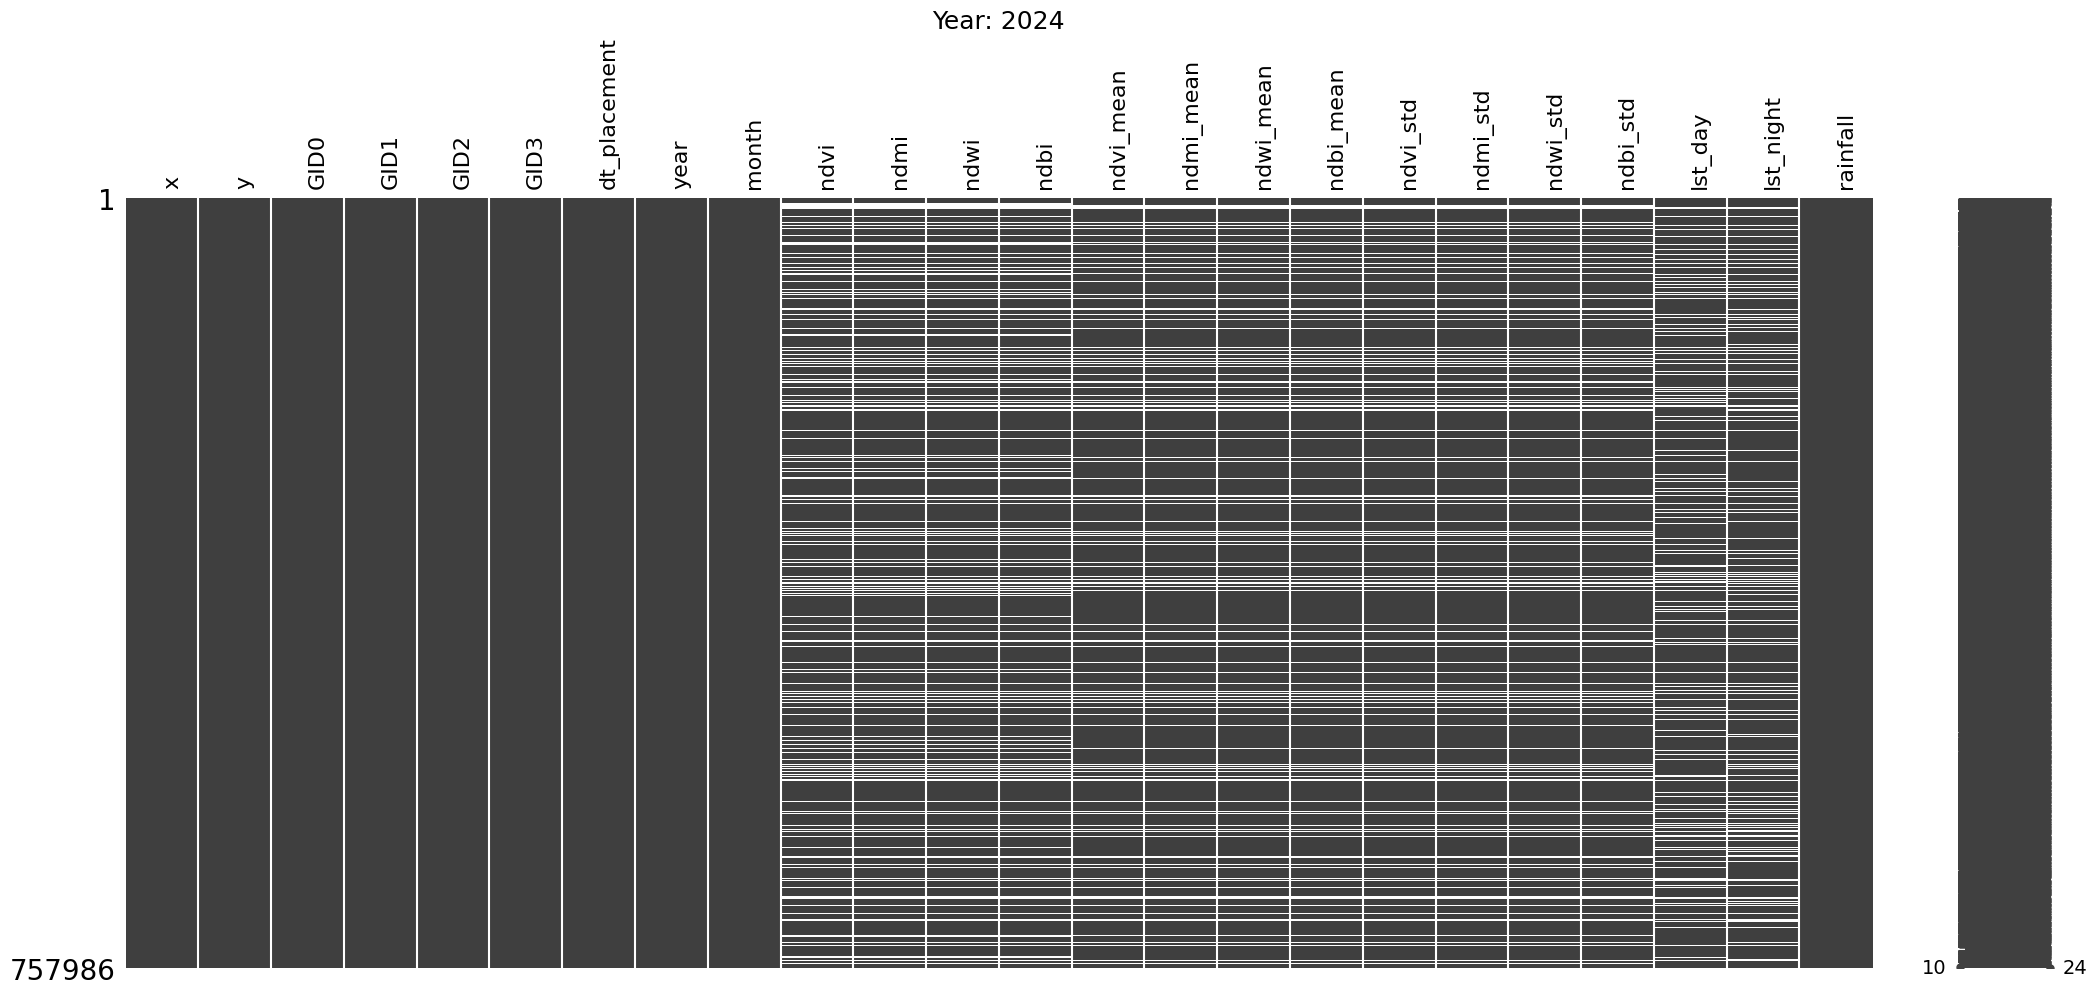

In [314]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [315]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [316]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [317]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00,15050.0,0.5,0.866
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43,15052.5,0.5,0.866
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14,15080.5,0.5,0.866
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10,15041.0,0.5,0.866
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06,15001.0,0.5,0.866


In [318]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [319]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [320]:
grouped_by_gid3 = timeline_file.groupby(['dt_placement', 'GID0','GID1','GID2','GID3'], as_index = False)
grouped_by_gid3_mean = grouped_by_gid3.mean()

In [321]:
grouped_by_gid3_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15411.133333,14581.866667,0.0,14996.500000,0.5,0.866
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15435.047619,14569.619048,0.0,15002.333333,0.5,0.866
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15388.750000,14638.666667,0.0,15014.500000,0.5,0.866
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15365.833333,14593.500000,0.0,14979.666667,0.5,0.866
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15425.750000,14593.833333,0.0,15007.833333,0.5,0.866


In [322]:
print(f'Shape of the grouped_by_gid3_mean file: {grouped_by_gid3_mean.shape}')

Shape of the grouped_by_gid3_mean file: (116022, 27)


Text(0.5, 1.0, 'Year: 2024.0')

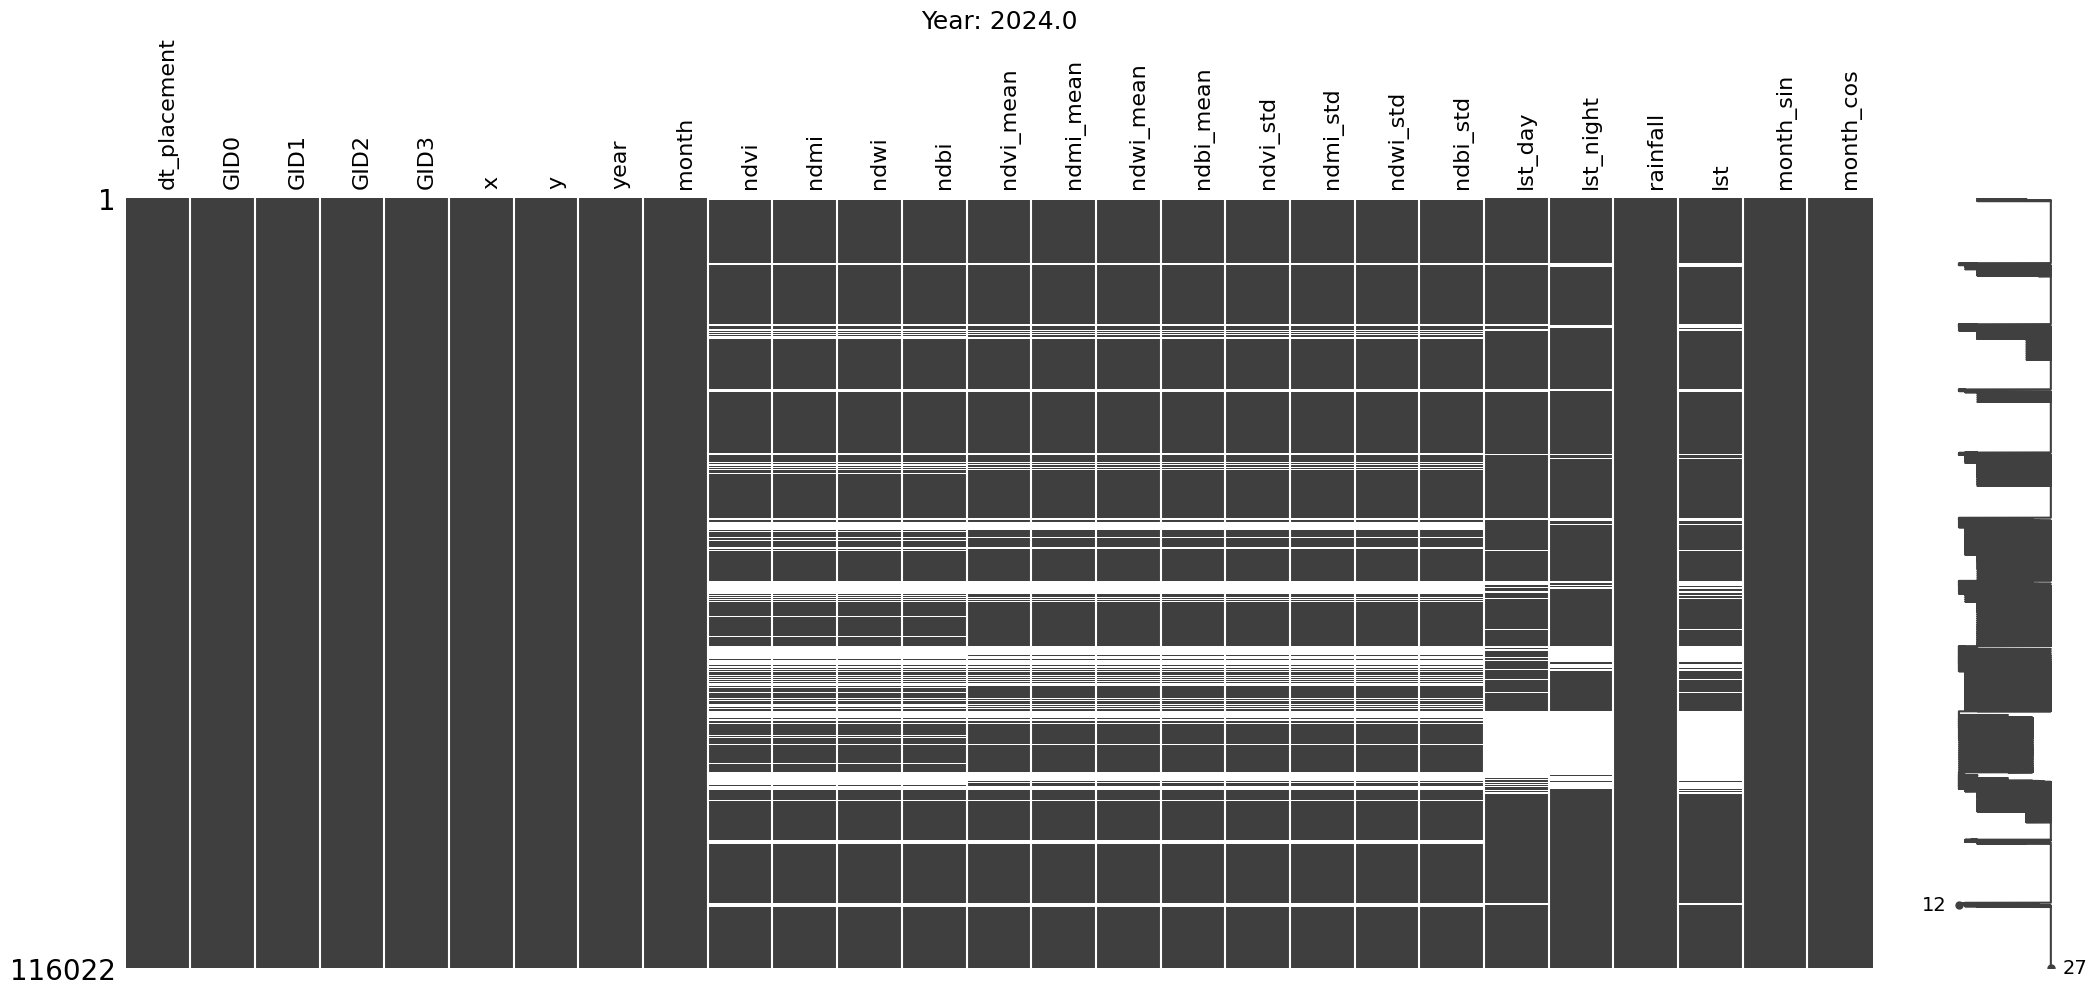

In [323]:
msno.matrix(grouped_by_gid3_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3_mean.year.iloc[0]}", fontsize=18)

In [324]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3_mean['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [325]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [326]:
grouped_by_gid3_mean = convert_temperature(grouped_by_gid3_mean)

In [327]:
grouped_by_gid3_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866


In [328]:
grouped_by_gid3_mean['year'] = grouped_by_gid3_mean['year'].astype(int)
grouped_by_gid3_mean['month'] = grouped_by_gid3_mean['month'].astype(int)

In [329]:
grouped_by_gid3_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866


Text(0.5, 1.0, 'Year: 2024')

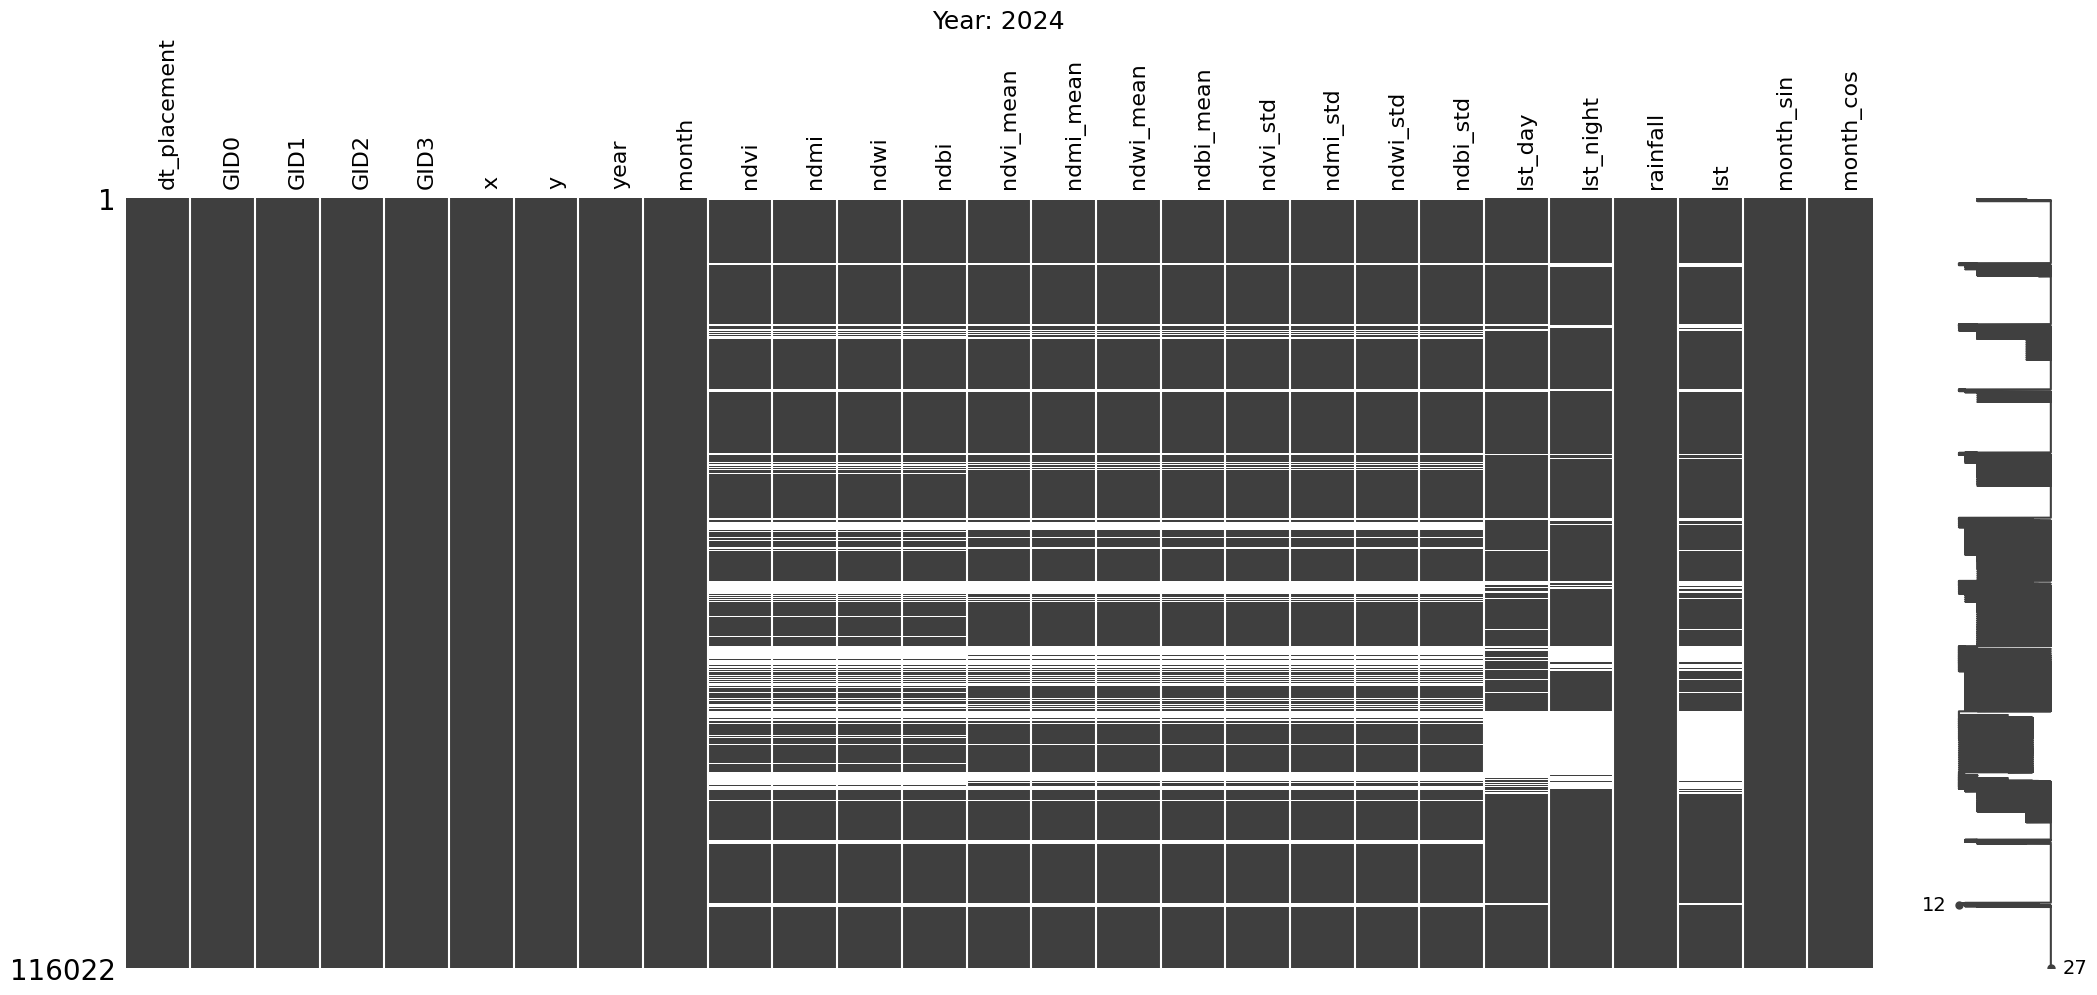

In [330]:
msno.matrix(grouped_by_gid3_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3_mean.year.iloc[0]}", fontsize=18)

In [331]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3_mean.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [332]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bogo,balaza,2024,1,14.866000,39.702000,0.000000
1,bogo,balaza,2024,2,19.018000,44.768667,0.055333
2,bogo,balaza,2024,3,19.016667,50.279333,0.959333
3,bogo,balaza,2024,4,21.765000,49.626000,4.331333
4,bogo,balaza,2024,5,22.142000,45.894000,27.415999
...,...,...,...,...,...,...,...
3799,yagoua,yagoua,2024,8,23.010000,29.799231,670.410754
3800,yagoua,yagoua,2024,9,NaN,NaN,274.622301
3801,yagoua,yagoua,2024,10,20.805385,34.750000,163.629996
3802,yagoua,yagoua,2024,11,15.173077,35.746923,0.000000


In [333]:
dataset = pd.merge(grouped_by_gid3_mean, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [334]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866,14.866000,39.702000,0.0
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866,15.075714,41.007143,0.0
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866,15.740000,39.240000,0.0
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866,14.863333,38.656667,0.0
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866,15.500000,40.417500,0.0


Text(0.5, 1.0, 'Year: 2024')

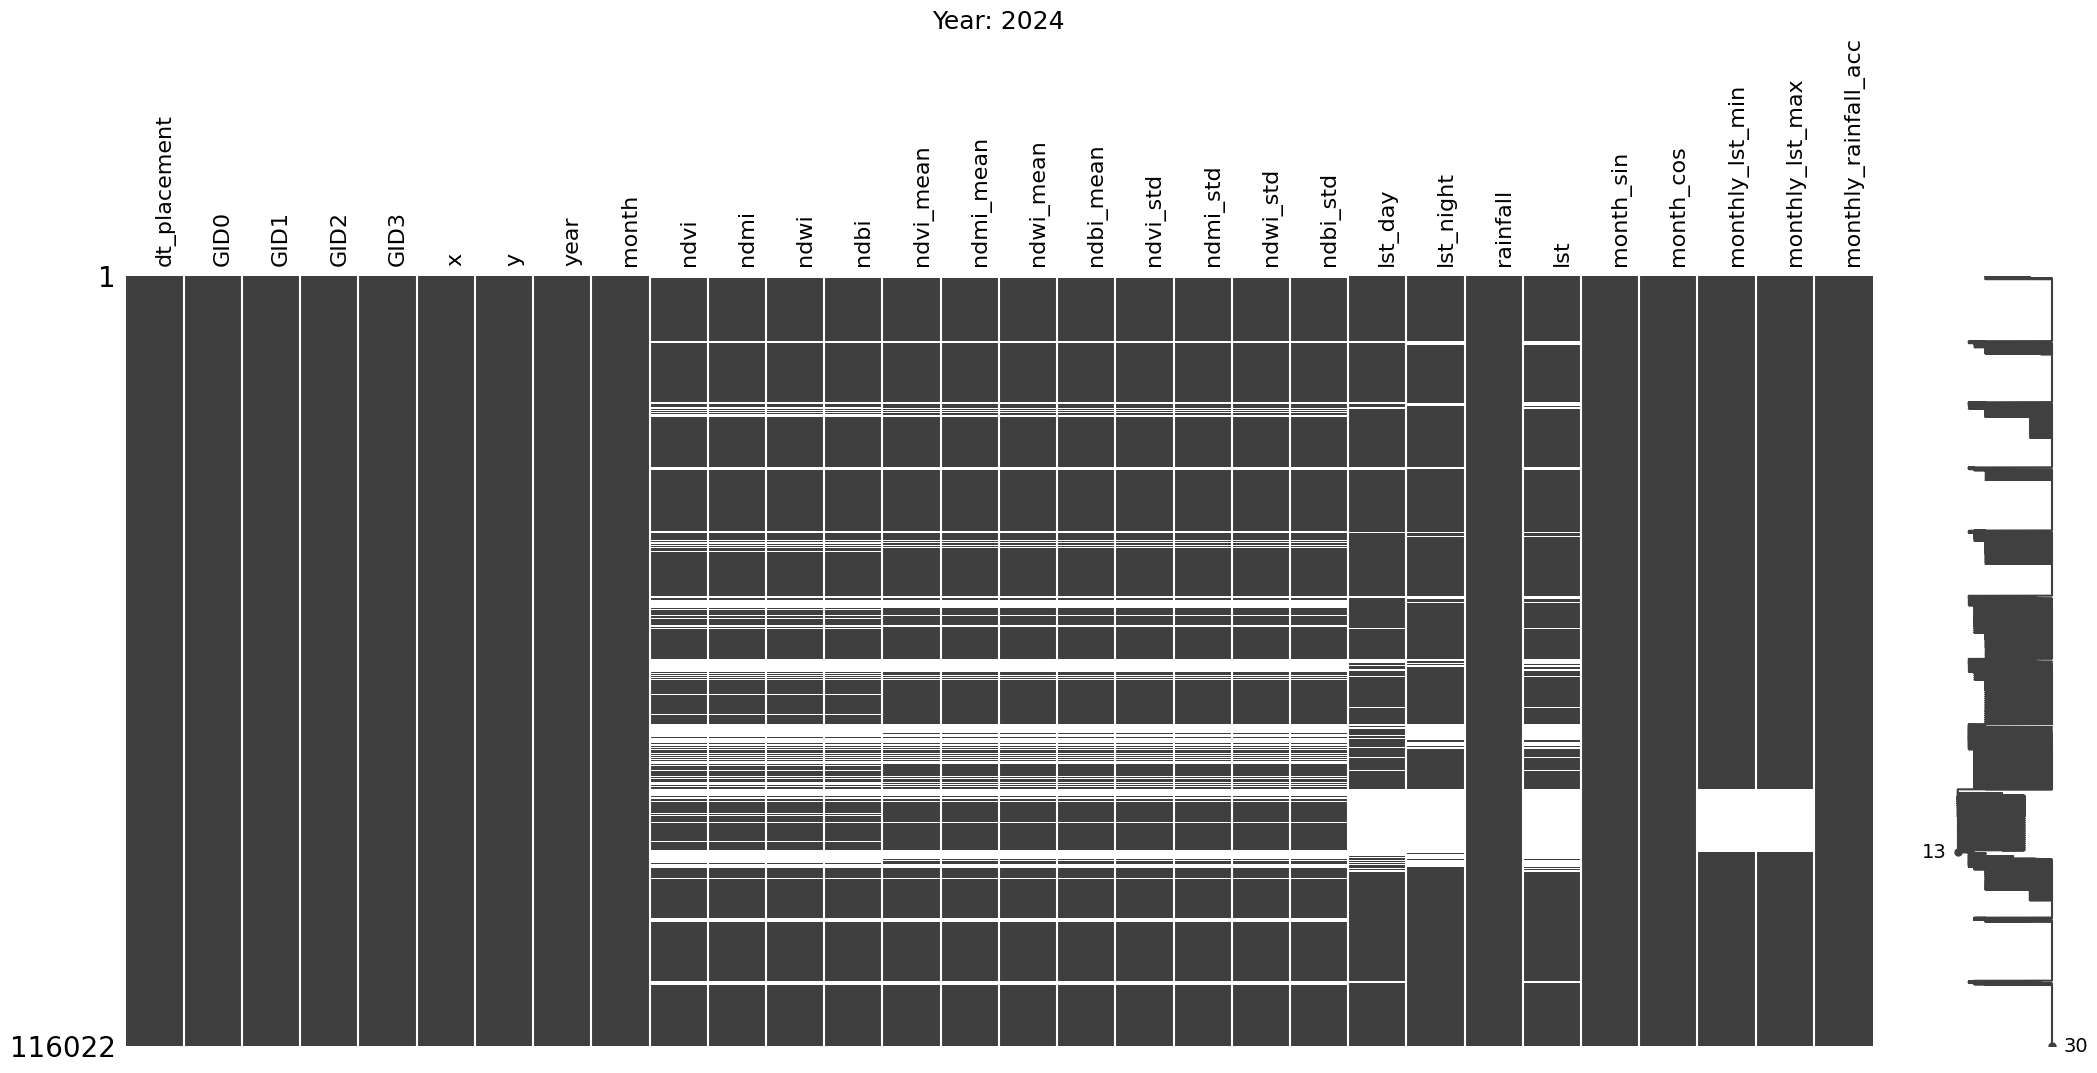

In [335]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [336]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [337]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866,14.866000,39.702000,0.0,2024-01
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866,15.075714,41.007143,0.0,2024-01
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866,15.740000,39.240000,0.0,2024-01
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866,14.863333,38.656667,0.0,2024-01
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866,15.500000,40.417500,0.0,2024-01


In [338]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [339]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [340]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024.0,1.0,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.0,27.122280,0.5,0.866,14.866000,39.702000,0.0
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024.0,1.0,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.0,27.627250,0.5,0.866,15.075714,41.007143,0.0
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024.0,1.0,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.0,27.101102,0.5,0.866,15.740000,39.240000,0.0
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024.0,1.0,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.0,26.627581,0.5,0.866,14.863333,38.656667,0.0
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024.0,1.0,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.0,27.474220,0.5,0.866,15.500000,40.417500,0.0


In [341]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (3804, 30)


Text(0.5, 1.0, 'Year: 2024.0')

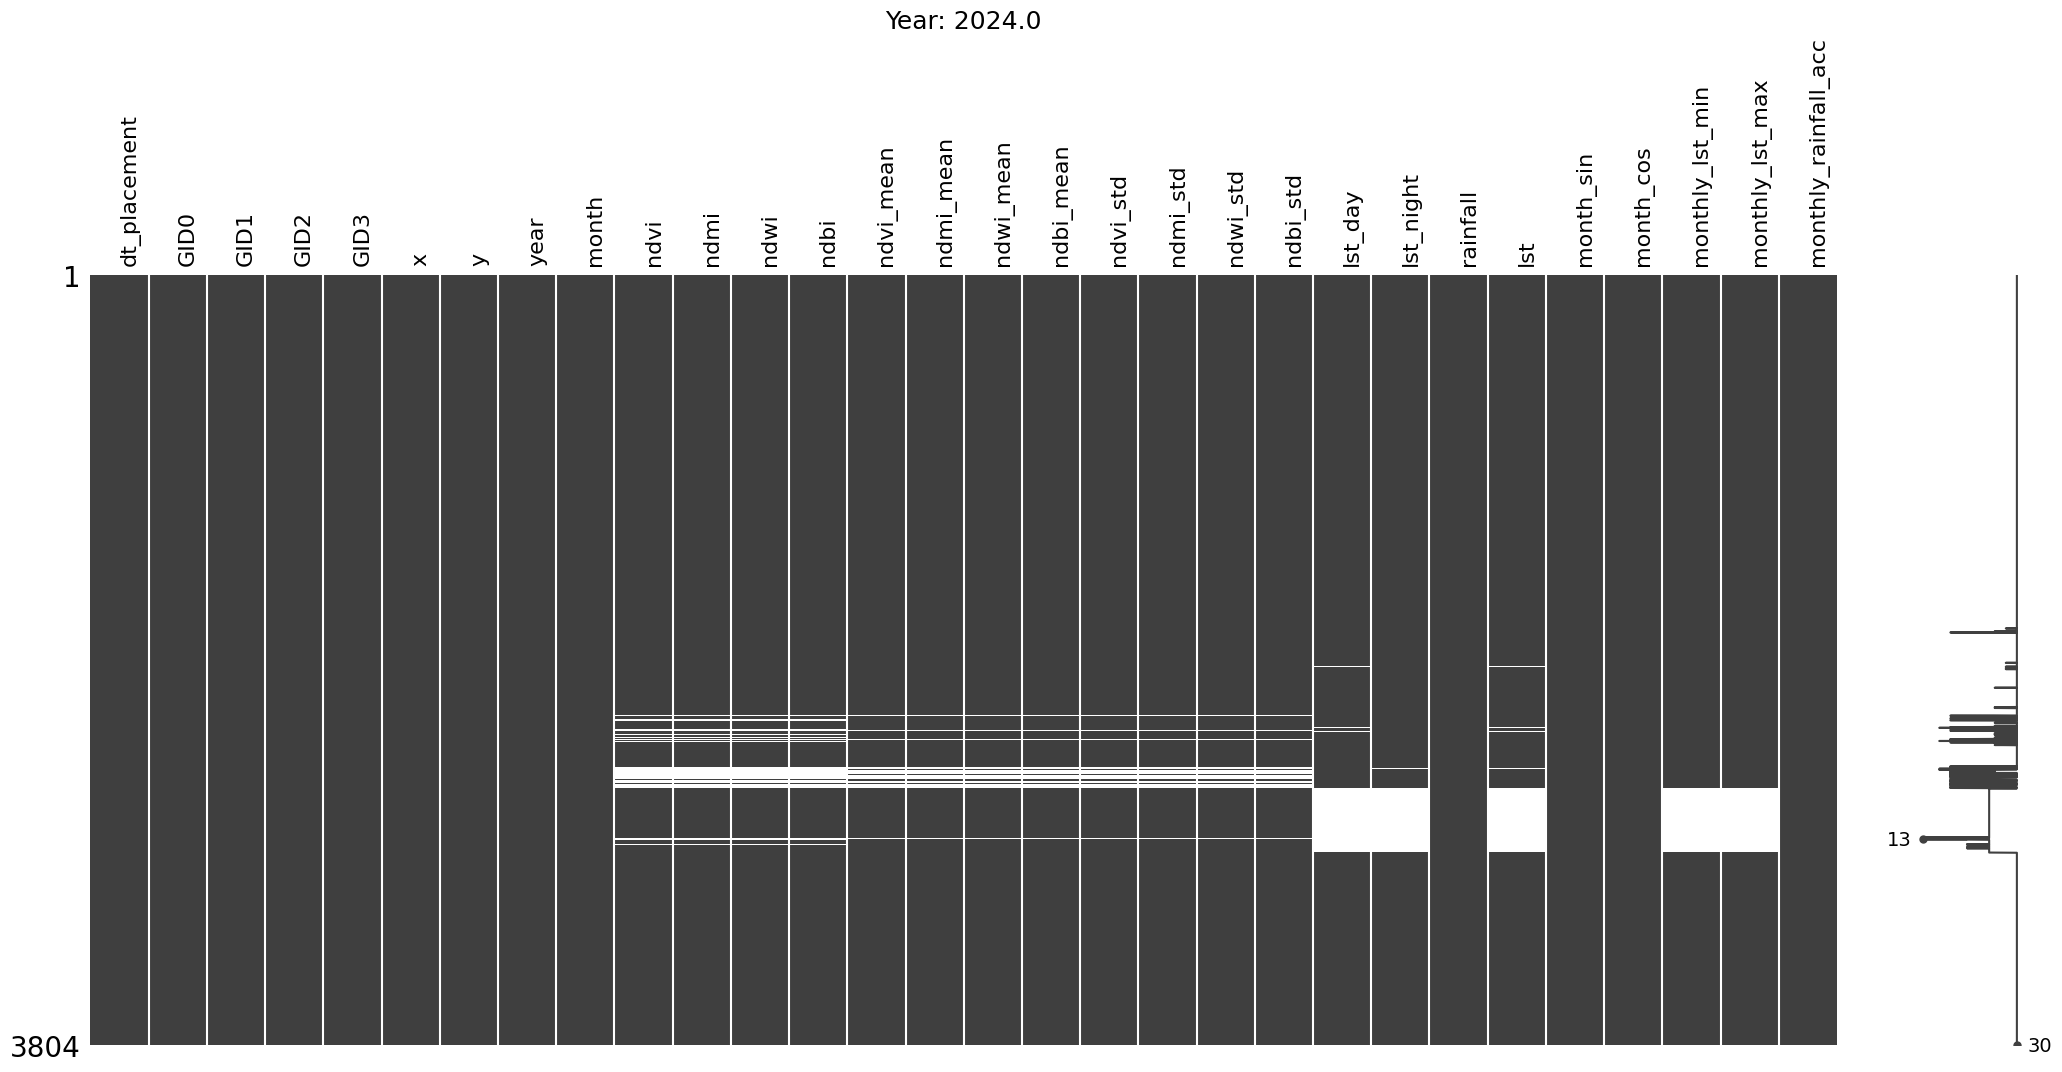

In [342]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [343]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [344]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [345]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [346]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.000000,27.122280,0.5,0.866,14.866000,39.702000,0.000000
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.000000,27.627250,0.5,0.866,15.075714,41.007143,0.000000
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.000000,27.101102,0.5,0.866,15.740000,39.240000,0.000000
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.000000,26.627581,0.5,0.866,14.863333,38.656667,0.000000
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.000000,27.474220,0.5,0.866,15.500000,40.417500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2024-12,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2024,12,0.225063,-0.138509,-0.333837,0.138509,0.231870,-0.128666,-0.337224,0.128666,0.008417,0.007810,0.008633,0.007810,29.990889,18.090000,0.046129,24.036333,0.0,1.000,15.843333,34.863333,1.430000
3800,2024-12,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,2024,12,0.244816,-0.116837,-0.331013,0.116837,0.255033,-0.110503,-0.336593,0.110503,0.019611,0.020640,0.014236,0.020640,29.349778,18.871505,0.039462,24.106556,0.0,1.000,16.383333,34.336667,1.223333
3801,2024-12,extreme nord,mayo-tsanaga,roua,roua,13.968570,10.779370,2024,12,0.261842,-0.092563,-0.336827,0.092563,0.239694,-0.117559,-0.326941,0.117559,0.027868,0.031638,0.016294,0.031638,29.430667,19.539677,0.021290,24.487000,0.0,1.000,17.210000,34.570000,0.660000
3802,2024-12,extreme nord,mayo-tsanaga,roua,soulede,13.917498,10.736254,2024,12,0.261371,-0.106492,-0.356389,0.106492,0.264671,-0.106488,-0.353364,0.106488,0.017699,0.015399,0.010047,0.015399,29.683867,17.587935,0.039355,23.621733,0.0,1.000,15.822000,35.122000,1.220000


In [347]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [348]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.0,27.122280,0.5,0.866,14.866000,39.702000,0.0,0.0
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.0,27.627250,0.5,0.866,15.075714,41.007143,0.0,0.0
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.0,27.101102,0.5,0.866,15.740000,39.240000,0.0,0.0
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.0,26.627581,0.5,0.866,14.863333,38.656667,0.0,0.0
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.0,27.474220,0.5,0.866,15.500000,40.417500,0.0,0.0


In [349]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [350]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [351]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.000000,27.122280,0.5,0.866,14.866000,39.702000,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.000000,27.627250,0.5,0.866,15.075714,41.007143,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.000000,27.101102,0.5,0.866,15.740000,39.240000,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.000000,26.627581,0.5,0.866,14.863333,38.656667,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.000000,27.474220,0.5,0.866,15.500000,40.417500,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2024-12,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2024,12,0.225063,-0.138509,-0.333837,0.138509,0.231870,-0.128666,-0.337224,0.128666,0.008417,0.007810,0.008633,0.007810,29.990889,18.090000,0.046129,24.036333,0.0,1.000,15.843333,34.863333,1.430000,1.430000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3800,2024-12,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,2024,12,0.244816,-0.116837,-0.331013,0.116837,0.255033,-0.110503,-0.336593,0.110503,0.019611,0.020640,0.014236,0.020640,29.349778,18.871505,0.039462,24.106556,0.0,1.000,16.383333,34.336667,1.223333,1.223333,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147

Text(0.5, 1.0, 'Year: 2024')

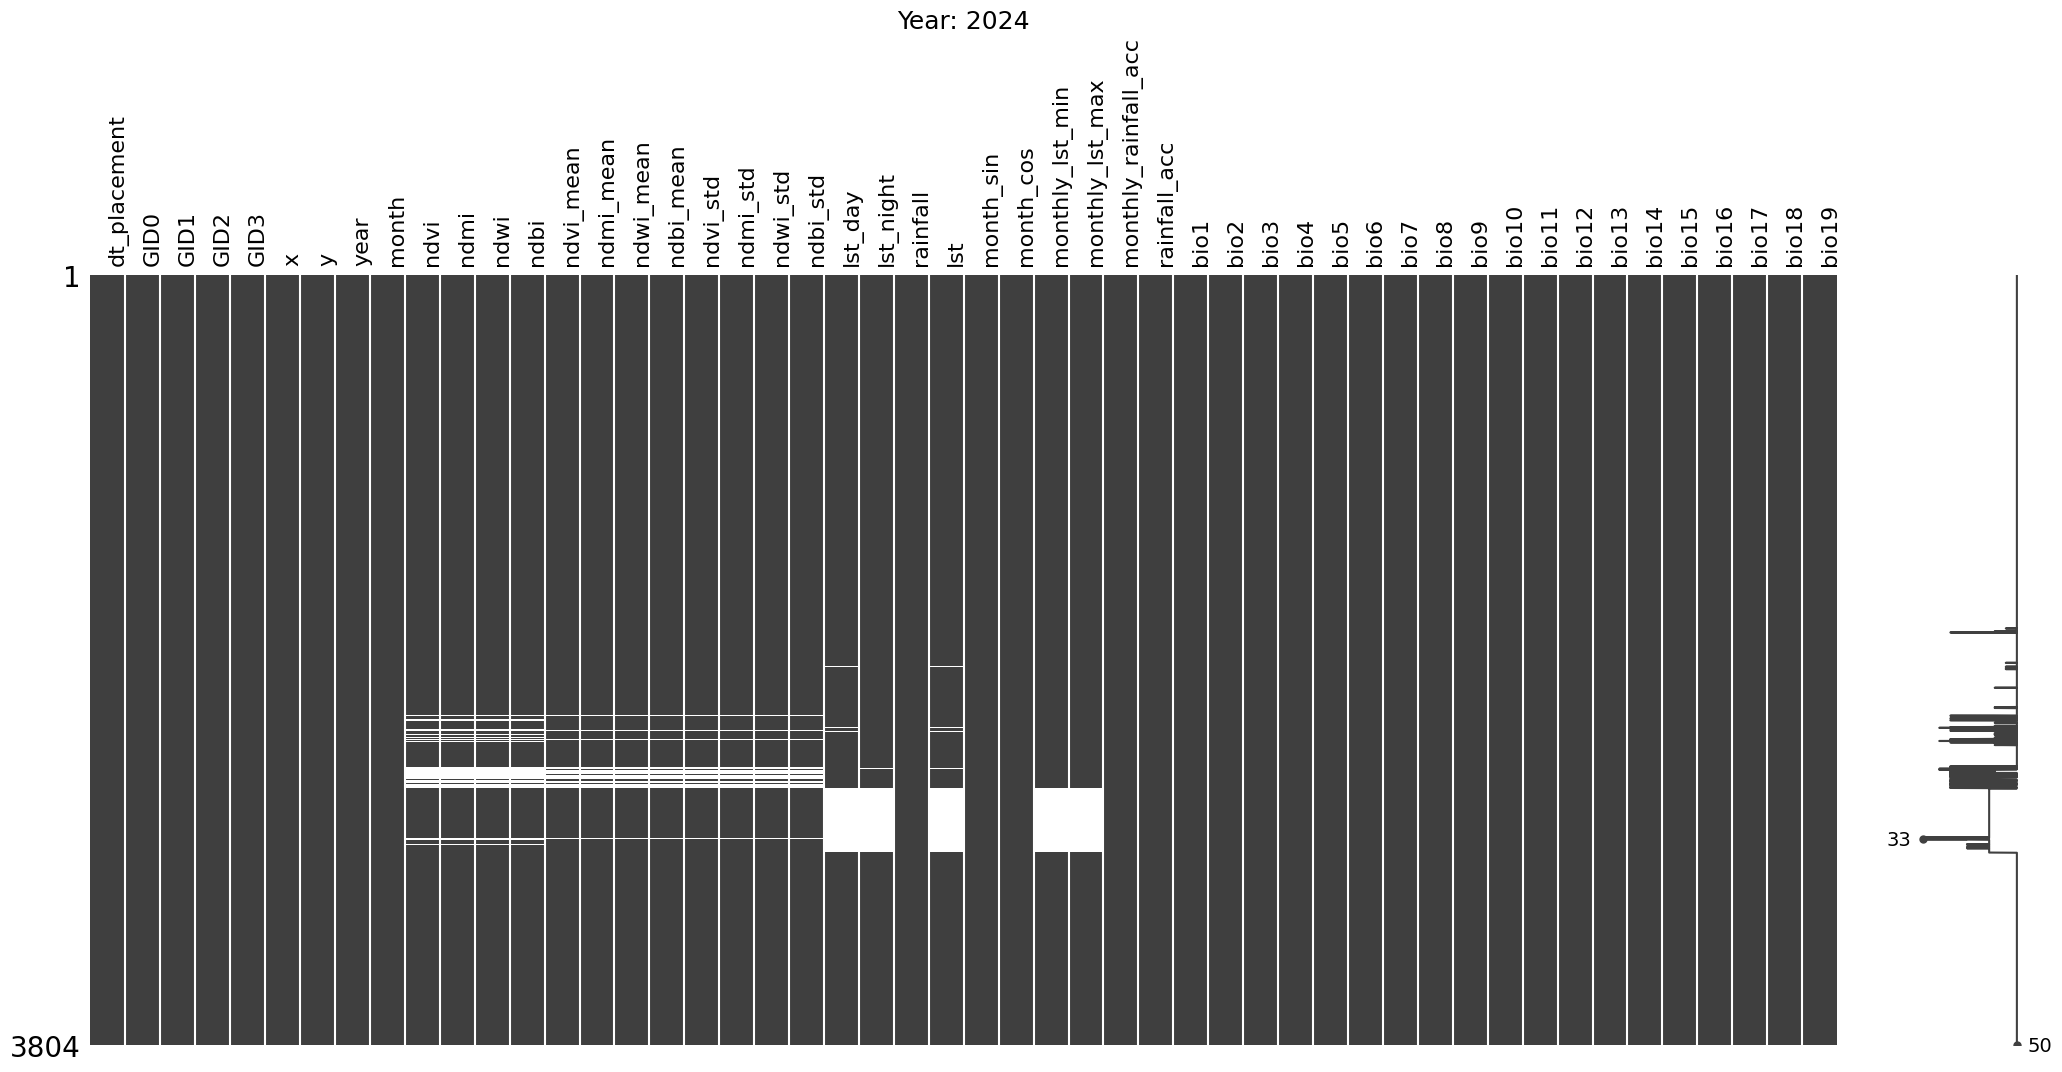

In [352]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [353]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)


In [354]:
new_order = ['dt_placement',
             'year',
             'month',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [355]:
dataset = dataset[new_order]

In [356]:
dataset.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0,0.0,0.0,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0,0.0,0.0,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0,0.0,0.0,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0,0.0,0.0,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0,0.0,0.0,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648


In [358]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3804 entries, 0 to 3803
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype    
---  ------                --------------  -----    
 0   dt_placement          3804 non-null   period[M]
 1   year                  3804 non-null   int32    
 2   month                 3804 non-null   int32    
 3   month_sin             3804 non-null   float64  
 4   month_cos             3804 non-null   float64  
 5   GID0                  3804 non-null   object   
 6   GID1                  3804 non-null   object   
 7   GID2                  3804 non-null   object   
 8   GID3                  3804 non-null   object   
 9   x                     3804 non-null   float64  
 10  y                     3804 non-null   float64  
 11  ndvi                  3665 non-null   float64  
 12  ndmi                  3665 non-null   float64  
 13  ndwi                  3665 non-null   float64  
 14  ndbi                  3665 non-null   fl

In [357]:
dataset.to_csv(f'../../data/ExtNord/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)